<span style="float: left;padding: 1.3em">![logo](Ligo.png)</span>
<span style="float: right;padding: 1.3em">![logo](Zewail-City.png)</span>

---
# Challenge #3 (_Intermediate_)

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
# Main Libraries
from pycbc.frame import read_frame
from pycbc.types import TimeSeries, FrequencySeries
from pycbc.filter import highpass, lowpass_fir, matched_filter
from pycbc.psd import welch, interpolate
from pycbc.waveform import get_td_waveform
import matplotlib.pyplot as plt
import numpy as np

### Use the data file challenge3.gwf with channel H1:CHALLENGE3.
### These are real LIGO data from O2, though we've adjusted the time labels and added some simulated signals.
### The data contain a loud simulated signal with m1 = m2 = 10 solar masses.

In [3]:
# Data
file_name = "challenge3.gwf"
channel = "H1:CHALLENGE3"

ts = read_frame(file_name, channel)

In [4]:
# Sampling rate
sampling_rate = ts.sample_rate
print("Sampling rate (Hz):", sampling_rate)

# Duration
duration = ts.duration
print("Duration (s):", duration)

Sampling rate (Hz): 4096.0
Duration (s): 4096.0


### What is the merger time of this signal?

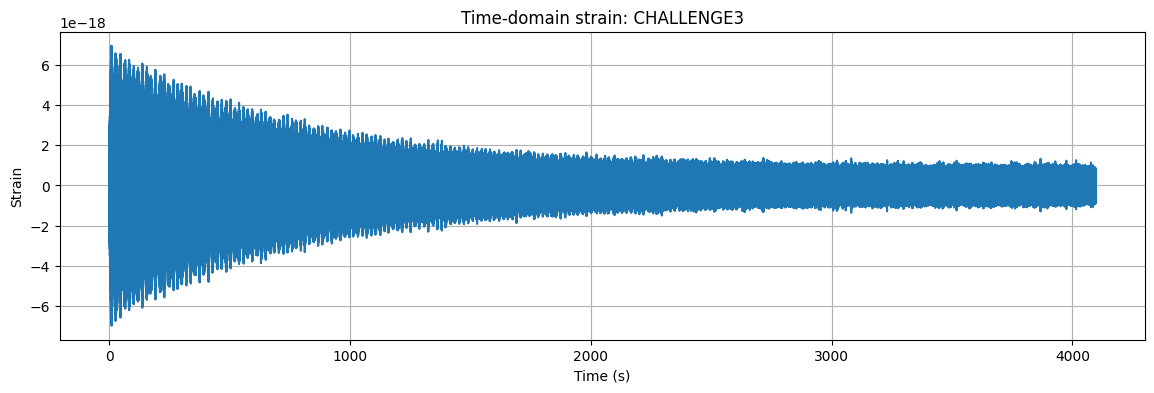

In [5]:
# Plot time-domain data
plt.figure(figsize=(14, 4))
plt.plot(ts.sample_times, ts)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Time-domain strain: CHALLENGE3")
plt.grid()
plt.show()

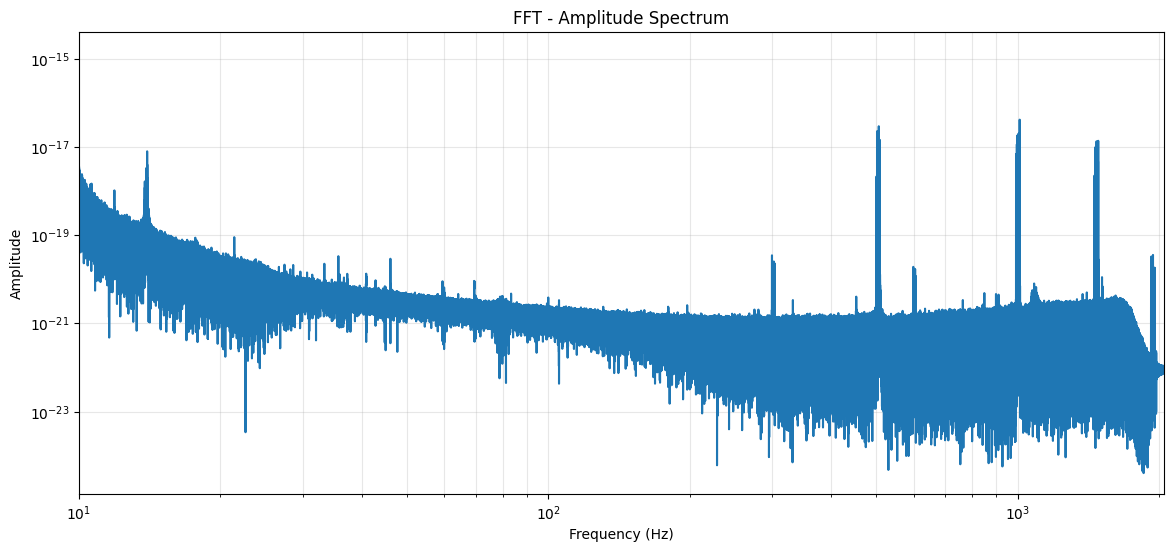

In [6]:
# Convert to frequency domain
ts_fft = ts.to_frequencyseries()

# Plot amplitude spectrum
plt.figure(figsize=(14, 6))
plt.loglog(ts_fft.sample_frequencies, abs(ts_fft))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT - Amplitude Spectrum")
plt.xlim(10, ts.sample_rate/2)
plt.grid(which='both', alpha=0.3)
plt.show()

In [7]:
# Highpass filter
ts_hp = highpass(ts, 30.0)

# Crop the edges to remove filter artifacts
crop_duration = 720  # Remove 6 min from each end
crop_samples = int(crop_duration * ts.sample_rate)
ts_filtered = ts_hp[crop_samples:-crop_samples]

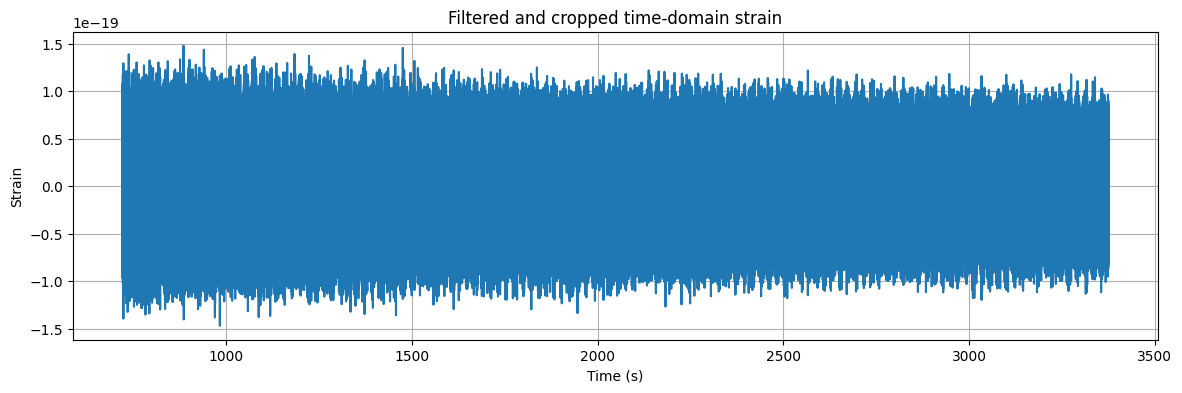

In [8]:
# Plot filtered and cropped data
plt.figure(figsize=(14, 4))
plt.plot(ts_filtered.sample_times, ts_filtered)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Filtered and cropped time-domain strain")
plt.grid()
plt.show()

In [9]:
print(f"Original duration: {ts.duration:.1f} s")
print(f"Filtered duration: {ts_filtered.duration:.1f} s")
print(f"Cropped: {crop_duration} s from each end")

Original duration: 4096.0 s
Filtered duration: 2656.0 s
Cropped: 720 s from each end


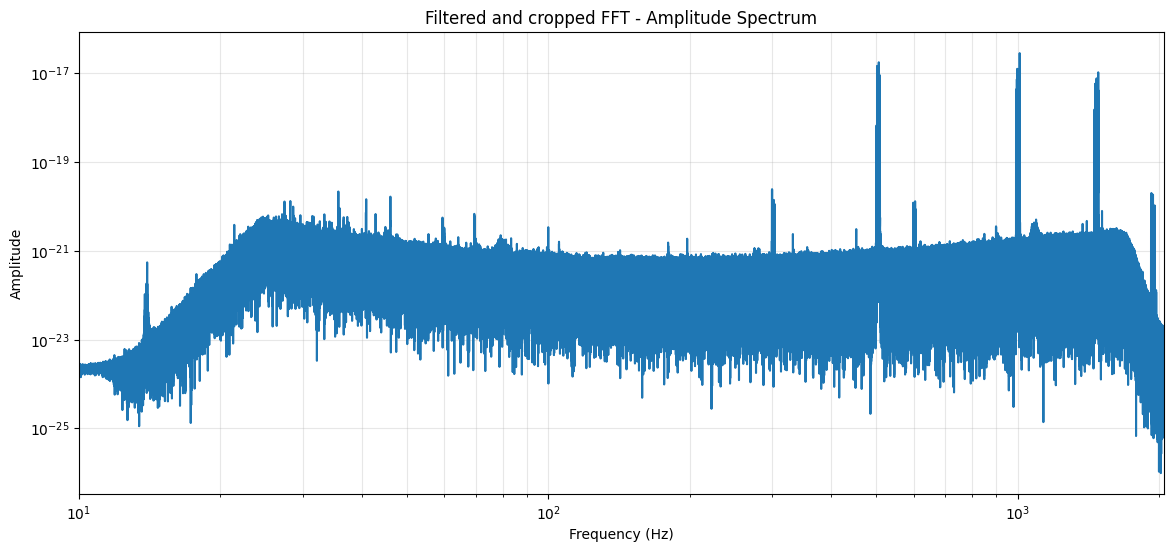

In [10]:
# Convert to frequency domain
ts_fft = ts_filtered.to_frequencyseries()

# Plot amplitude spectrum
plt.figure(figsize=(14, 6))
plt.loglog(ts_fft.sample_frequencies, abs(ts_fft))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Filtered and cropped FFT - Amplitude Spectrum")
plt.xlim(10, ts.sample_rate/2)
plt.grid(which='both', alpha=0.3)
plt.show()

### Generate a time-domain template waveform using approximate `SEOBNRv4_opt`.

In [11]:
# Generate template waveform for m1 = m2 = 10 solar masses
hp, hc = get_td_waveform(
    approximant='SEOBNRv4_opt',
    mass1=10,
    mass2=10,
    spin1z=0,
    spin2z=0,
    delta_t=1.0/ts_filtered.sample_rate,
    f_lower=30.0
)


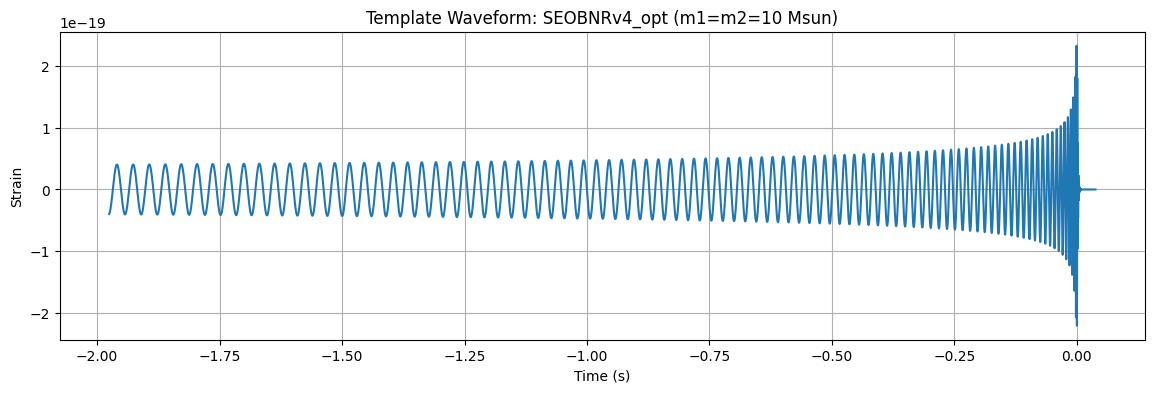

In [12]:
# Plot
plt.figure(figsize=(14, 4))
plt.plot(hp.sample_times, hp)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Template Waveform: SEOBNRv4_opt (m1=m2=10 Msun)")
plt.grid()
plt.show()

### Calculate a PSD of the data, and plot this on a log-log scale. 

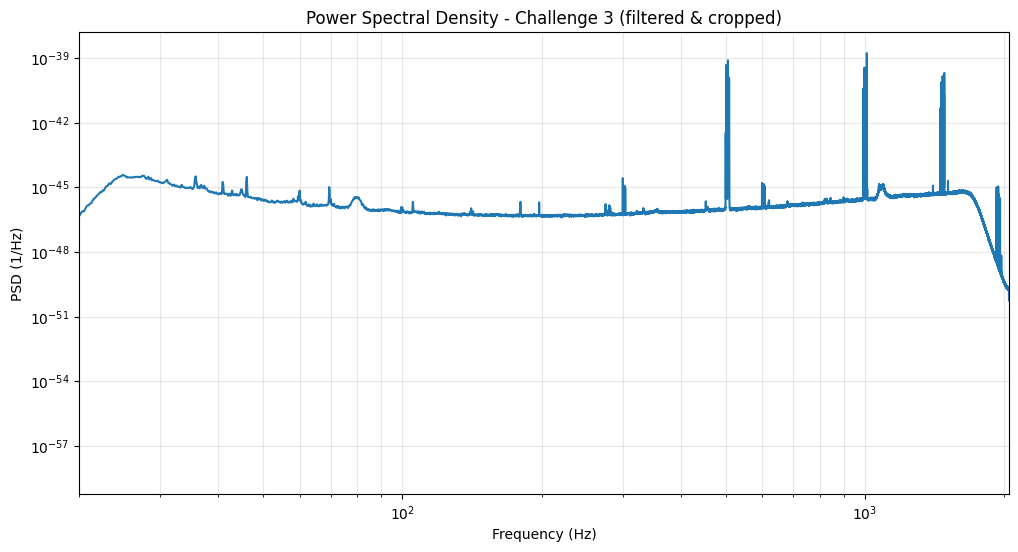

In [13]:
# Calculate PSD using Welch method
psd = welch(ts_filtered, seg_len=int(8*ts_filtered.sample_rate), seg_stride=int(4*ts_filtered.sample_rate))

# Plot PSD
nyquist_freq = ts_filtered.sample_rate / 2
plt.figure(figsize=(12, 6))
plt.loglog(psd.sample_frequencies, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (1/Hz)")
plt.title("Power Spectral Density - Challenge 3 (filtered & cropped)")
plt.xlim(20, nyquist_freq)
plt.grid(which='both', alpha=0.3)
plt.show()

### Use the template waveform and PSD to calculate the SNR time series. Plot the SNR time-series.

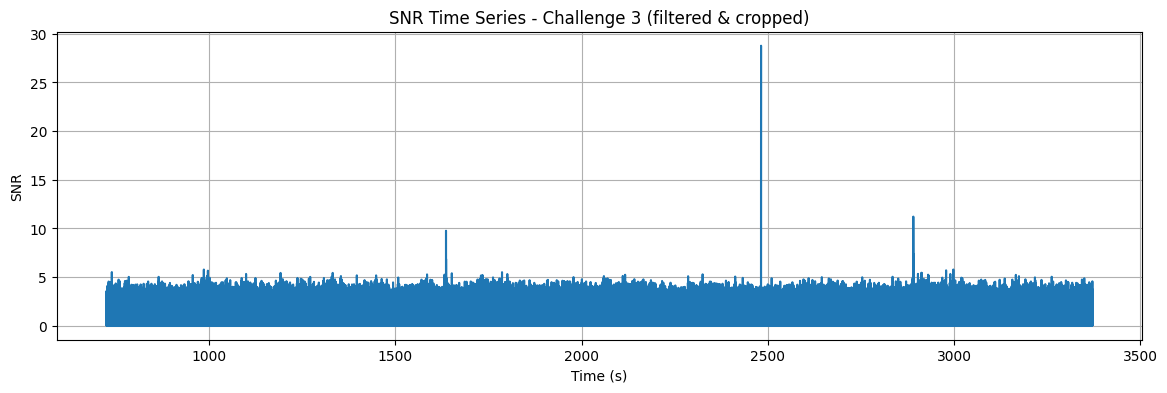

In [14]:
# Calculate matched filter SNR
hp.resize(len(ts_filtered))
psd_interp = interpolate(psd, hp.delta_f)

snr = matched_filter(hp, ts_filtered, psd=psd_interp, low_frequency_cutoff=30.0)

# CROP SNR to remove edge artifacts from matched filtering
snr_crop_duration = 4 # Remove 4 seconds from each end of SNR
snr_crop_samples = int(snr_crop_duration * snr.sample_rate)
snr = snr[snr_crop_samples:-snr_crop_samples]

# Plot SNR time series
plt.figure(figsize=(14, 4))
plt.plot(snr.sample_times, abs(snr))
plt.xlabel("Time (s)")
plt.ylabel("SNR")
plt.title("SNR Time Series - Challenge 3 (filtered & cropped)")
plt.grid()
plt.show()

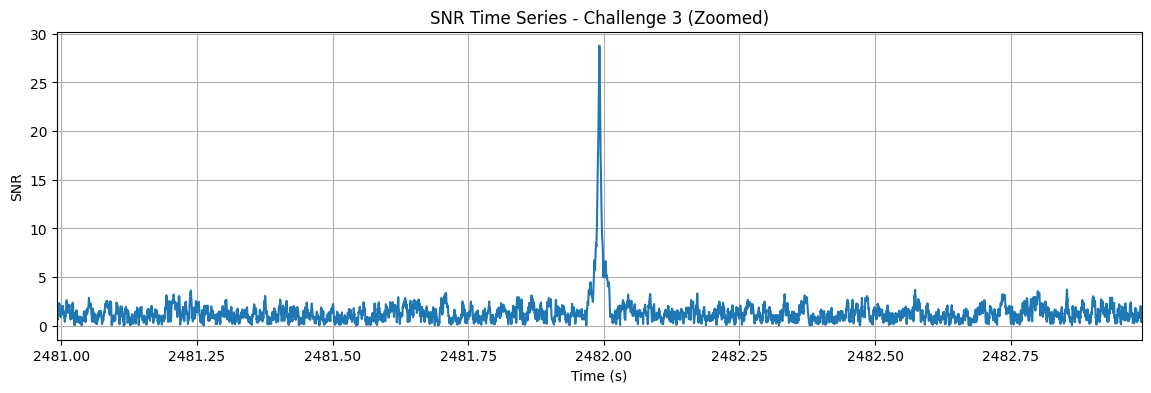

In [15]:
# Zoom in on the peak
peak_snr_index = np.argmax(abs(snr))
peak_time = snr.sample_times[peak_snr_index]
plt.figure(figsize=(14, 4))
plt.plot(snr.sample_times, abs(snr))
plt.xlabel("Time (s)")
plt.ylabel("SNR")
plt.title("SNR Time Series - Challenge 3 (Zoomed)")
plt.xlim(peak_time - 1, peak_time + 1)
plt.grid()
plt.show()

### SNR of the signal

In [16]:
peak_snr_index = np.argmax(abs(snr))
peak_snr = abs(snr[peak_snr_index])
merger_time = snr.sample_times[peak_snr_index]

print("Matched filter SNR:", peak_snr)
print("Merger time:", merger_time, "s")

Matched filter SNR: 28.7784733140847
Merger time: 2481.991943359375 s


---